# Estrategia de obtención de nuevos datos

## Data Augmentation Strategy

El aumento de datos es una técnica que expande artificialmente un conjunto de datos mediante la creación de versiones modificadas de los datos existentes, así que vamos a aplicar esto principalmente para aumentar el dataset.

In [32]:
!pip3 install albumentations
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import albumentations as A
from pathlib import Path
import random
import pandas as pd
import seaborn as sns

np.random.seed(42)
random.seed(42)

In [33]:
def create_augmentation_pipeline():
    """
    Crea un pipeline de augmentation con Albumentations
    """
    return A.Compose([
        # Transformaciones geométricas
        A.RandomRotate90(p=0.5),
        A.Rotate(limit=30, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.8, 1.2), translate_percent=(-0.2, 0.2), p=0.5),
        
        # Transformaciones de color/intensidad
        A.RandomBrightnessContrast(p=0.5),
        A.GaussNoise(p=0.3),
        A.Blur(blur_limit=3, p=0.3),
        
        # Transformaciones específicas para señas
        A.OneOf([
            A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
            A.GridDistortion(p=0.5),
            A.OpticalDistortion(distort_limit=1, shift_limit=0.5, p=0.5),
        ], p=0.3),
        
        # Transformaciones de fondo
        A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3)
    ])

In [34]:
def visualize_augmentations(image, num_samples=5):
    """
    Visualiza diferentes augmentations aplicadas a una imagen
    """
    augmentor = create_augmentation_pipeline()
    
    plt.figure(figsize=(15, 3))
    plt.subplot(1, num_samples + 1, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original')
    plt.axis('off')
    
    for i in range(num_samples):
        augmented = augmentor(image=image)['image']
        plt.subplot(1, num_samples + 1, i + 2)
        plt.imshow(cv2.cvtColor(augmented, cv2.COLOR_BGR2RGB))
        plt.title(f'Augmented {i+1}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [35]:
def augment_dataset(input_dir, output_dir, augmentations_per_image=3):
    """
    Aplica data augmentation al dataset completo
    """
    augmentor = create_augmentation_pipeline()
    
    # Estadísticas
    stats = {
        'categoria': [],
        'imagenes_originales': [],
        'imagenes_aumentadas': []
    }
    
    # Procesar cada categoría
    for categoria in tqdm(os.listdir(input_dir)):
        cat_dir = os.path.join(input_dir, categoria)
        if not os.path.isdir(cat_dir):
            continue
            
        # Crear directorio de salida para la categoría
        out_cat_dir = os.path.join(output_dir, categoria)
        os.makedirs(out_cat_dir, exist_ok=True)
        
        # Procesar imágenes
        images = [f for f in os.listdir(cat_dir) if f.lower().endswith('.jpg')]
        
        for img_name in images:
            # Leer imagen
            img_path = os.path.join(cat_dir, img_name)
            image = cv2.imread(img_path)
            
            if image is None:
                continue
                
            # Generar augmentations
            for i in range(augmentations_per_image):
                augmented = augmentor(image=image)['image']
                # Guardar imagen aumentada
                aug_name = f"{os.path.splitext(img_name)[0]}_aug_{i}{os.path.splitext(img_name)[1]}"
                cv2.imwrite(os.path.join(out_cat_dir, aug_name), augmented)
        
        # Actualizar estadísticas
        stats['categoria'].append(categoria)
        stats['imagenes_originales'].append(len(images))
        stats['imagenes_aumentadas'].append(len(images) * augmentations_per_image)
    
    return pd.DataFrame(stats)

Ejemplos de augmentation para una imagen:


/var/folders/4g/g5ksp9y97_q8j7kpwfyq3dg80000gn/T/ipykernel_25473/3767521322.py:19: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
/var/folders/4g/g5ksp9y97_q8j7kpwfyq3dg80000gn/T/ipykernel_25473/3767521322.py:21: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=1, shift_limit=0.5, p=0.5),
/var/folders/4g/g5ksp9y97_q8j7kpwfyq3dg80000gn/T/ipykernel_25473/3767521322.py:25: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3)


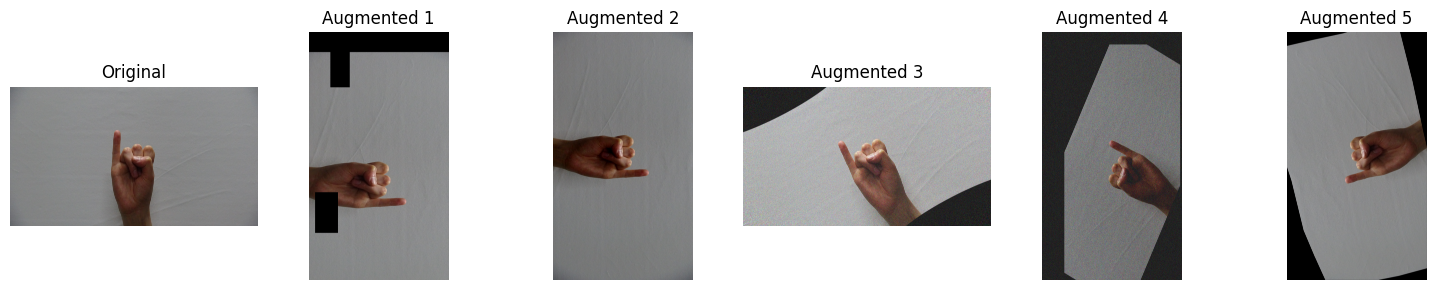


Aplicando data augmentation al dataset completo...


100%|██████████| 20/20 [23:09<00:00, 69.47s/it]


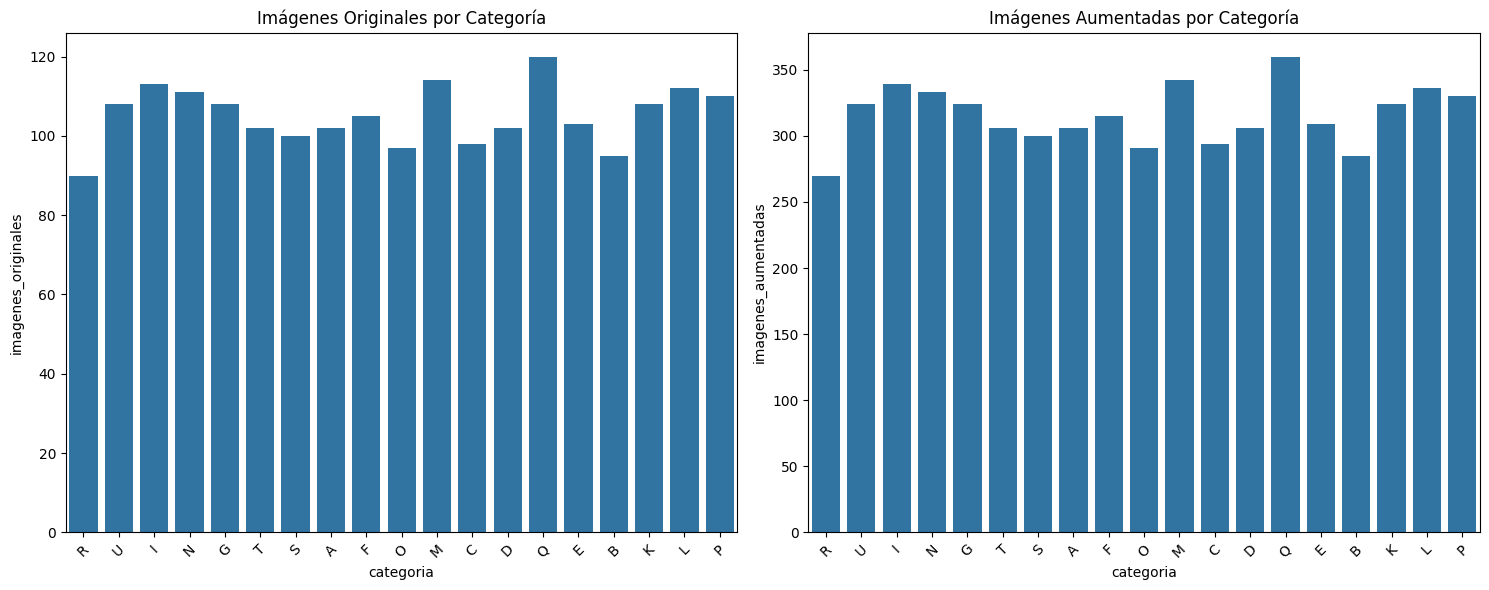


Resumen de augmentation:
Total imágenes originales: 1998
Total imágenes aumentadas: 5994
Factor de aumento: 3.00x


In [36]:
input_dataset = "/Users/andres/proyecto_final/Real-Time-Spanish-Sign-Language-Recognition/datasets/SSLdictionary"
output_dataset = "/Users/andres/proyecto_final/Real-Time-Spanish-Sign-Language-Recognition/datasets/SSLdictionary_augmented"

sample_category = random.choice(os.listdir(input_dataset))
sample_image_path = os.path.join(input_dataset, sample_category, 
                                os.listdir(os.path.join(input_dataset, sample_category))[0])
sample_image = cv2.imread(sample_image_path)

print("Ejemplos de augmentation para una imagen:")
visualize_augmentations(sample_image)

print("\nAplicando data augmentation al dataset completo...")
stats_df = augment_dataset(input_dataset, output_dataset)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.barplot(data=stats_df, x='categoria', y='imagenes_originales')
plt.title('Imágenes Originales por Categoría')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(data=stats_df, x='categoria', y='imagenes_aumentadas')
plt.title('Imágenes Aumentadas por Categoría')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nResumen de augmentation:")
print(f"Total imágenes originales: {stats_df['imagenes_originales'].sum()}")
print(f"Total imágenes aumentadas: {stats_df['imagenes_aumentadas'].sum()}")
print(f"Factor de aumento: {stats_df['imagenes_aumentadas'].sum() / stats_df['imagenes_originales'].sum():.2f}x")